# PCOS Prediction Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\WELCOME\Desktop\PCOS-Disease-Prediction\processed\pcos_cleaned.csv")

In [3]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58
0,1.0,1.0,0.0,28.0,44.6,152.0,19.30,15.0,78.0,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,2.0,0.0,36.0,65.0,161.5,24.92,15.0,74.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,3.0,1.0,33.0,68.8,165.0,25.27,11.0,72.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,4.0,0.0,37.0,65.0,148.0,29.67,13.0,72.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,5.0,0.0,25.0,52.0,161.0,20.06,11.0,72.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

Sl. No                    458
Patient File No.          458
PCOS (Y/N)                458
 Age (yrs)                458
Weight (Kg)               458
Height(Cm)                458
BMI                       458
Blood Group               458
Pulse rate(bpm)           458
RR (breaths/min)          458
Hb(g/dl)                  458
Cycle(R/I)                458
Cycle length(days)        458
Marraige Status (Yrs)     459
Pregnant(Y/N)             458
No. of aborptions         458
  I   beta-HCG(mIU/mL)    458
II    beta-HCG(mIU/mL)    458
FSH(mIU/mL)               458
LH(mIU/mL)                458
FSH/LH                    458
Hip(inch)                 458
Waist(inch)               458
Waist:Hip Ratio           458
TSH (mIU/L)               458
AMH(ng/mL)                458
PRL(ng/mL)                458
Vit D3 (ng/mL)            458
PRG(ng/mL)                458
RBS(mg/dl)                458
Weight gain(Y/N)          458
hair growth(Y/N)          458
Skin darkening (Y/N)      458
Hair loss(

In [5]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [6]:
df = df.dropna(how="all")

In [7]:
df.shape

(540, 44)

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df = df.rename(columns={
    "Sl. No": "sr_no",
    "Patient File No.": "patient_id",
    "PCOS (Y/N)": "pcos",
    "Age (yrs)": "age_yrs",
    "Weight (Kg)": "weight_kg",
    "Height(Cm)": "height_cm",
    "BMI": "bmi",
    "Blood Group": "blood_group",
    "Pulse rate(bpm)": "pulse_rate",
    "RR (breaths/min)": "respiratory_rate",
    "Hb(g/dl)": "hb",
    "Cycle(R/I)": "cycle_type",
    "Cycle length(days)": "cycle_length",
    "Marraige Status (Yrs)": "marriage_yrs",
    "Pregnant(Y/N)": "pregnant",
    "No. of abortions": "abortions",
    "I beta-HCG(mIU/mL)": "beta_hcg_1",
    "II beta-HCG(mIU/mL)": "beta_hcg_2",
    "FSH(mIU/mL)": "fsh",
    "LH(mIU/mL)": "lh",
    "FSH/LH": "fsh_lh_ratio",
    "Hip(inch)": "hip_inch",
    "Waist(inch)": "waist_inch",
    "Waist:Hip Ratio": "waist_hip_ratio",
    "TSH (mIU/L)": "tsh",
    "AMH(ng/mL)": "amh",
    "PRL(ng/mL)": "prolactin",
    "Vit D3 (ng/mL)": "vit_d3",
    "PRG(ng/mL)": "progesterone",
    "RBS(mg/dl)": "rbs",
    "Weight gain(Y/N)": "weight_gain",
    "hair growth(Y/N)": "hair_growth",
    "Skin darkening (Y/N)": "skin_darkening",
    "Hair loss(Y/N)": "hair_loss",
    "Pimples(Y/N)": "pimples",
    "Fast food (Y/N)": "fast_food",
    "Reg.Exercise(Y/N)": "exercise",
    "BP _Systolic (mmHg)": "bp_sys",
    "BP _Diastolic (mmHg)": "bp_dia",
    "Follicle No. (L)": "follicle_left",
    "Follicle No. (R)": "follicle_right",
    "Avg. F size (L) (mm)": "follicle_size_left",
    "Avg. F size (R) (mm)": "follicle_size_right",
    "Endometrium (mm)": "endometrium"
})

In [10]:
list(df.columns)

['sr_no',
 'patient_id',
 'pcos',
 'age_yrs',
 'weight_kg',
 'height_cm',
 'bmi',
 'blood_group',
 'pulse_rate',
 'respiratory_rate',
 'hb',
 'cycle_type',
 'cycle_length',
 'marriage_yrs',
 'pregnant',
 'No. of aborptions',
 'I   beta-HCG(mIU/mL)',
 'II    beta-HCG(mIU/mL)',
 'fsh',
 'lh',
 'fsh_lh_ratio',
 'hip_inch',
 'waist_inch',
 'waist_hip_ratio',
 'tsh',
 'amh',
 'prolactin',
 'vit_d3',
 'progesterone',
 'rbs',
 'weight_gain',
 'hair_growth',
 'skin_darkening',
 'hair_loss',
 'pimples',
 'fast_food',
 'exercise',
 'bp_sys',
 'bp_dia',
 'follicle_left',
 'follicle_right',
 'follicle_size_left',
 'follicle_size_right',
 'endometrium']

## Rename Columns

In [11]:
df = df.rename(columns={
    "No. of abortions": "abortions",
    "I   beta-HCG(mIU/mL)": "beta_hcg_1",
    "II    beta-HCG(mIU/mL)": "beta_hcg_2"
})

## Fix Data Types

In [12]:
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
df["beta_hcg_2"] = pd.to_numeric(df["beta_hcg_2"], errors="coerce")
df["amh"] = pd.to_numeric(df["amh"], errors="coerce")

In [13]:
df.isnull().sum().sort_values(ascending=False)

bmi                    1
amh                    1
beta_hcg_2             1
marriage_yrs           1
fast_food              1
weight_kg              0
height_cm              0
blood_group            0
age_yrs                0
sr_no                  0
pcos                   0
patient_id             0
cycle_type             0
hb                     0
respiratory_rate       0
pulse_rate             0
No. of aborptions      0
beta_hcg_1             0
fsh                    0
pregnant               0
lh                     0
fsh_lh_ratio           0
waist_inch             0
hip_inch               0
waist_hip_ratio        0
tsh                    0
prolactin              0
cycle_length           0
vit_d3                 0
progesterone           0
weight_gain            0
rbs                    0
hair_growth            0
skin_darkening         0
hair_loss              0
pimples                0
exercise               0
bp_sys                 0
bp_dia                 0
follicle_left          0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.dropna()

In [16]:
df.shape

(535, 44)

## Split Features and Target

### Purpose
The dataset is divided into input features (`x`) and the target variable (`y`). The model will use clinical and lifestyle-related features to predict PCOS status.

In [17]:
x = df.drop("pcos", axis=1)

y = df["pcos"]

## Train Test Split

### Purpose
The dataset is divided into training and testing sets. The training data is used to train the machine learning model, while the testing data is used to evaluate prediction performance.

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
x_train.shape

(428, 43)

## Feature Scaling

### Purpose
Feature scaling standardizes numerical values into a similar range, helping the machine learning model learn patterns more effectively.

In [20]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

## Logistic Regression Model

### Purpose
Logistic Regression is a classification algorithm used to predict whether a patient has PCOS based on clinical and lifestyle-related features.

In [21]:
log_model = LogisticRegression()

log_model.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
y_pred_log = log_model.predict(x_test_scaled)

In [23]:
y_pred_log = log_model.predict(x_test_scaled)

In [24]:
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.8785046728971962


In [25]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91        69
         1.0       0.90      0.74      0.81        38

    accuracy                           0.88       107
   macro avg       0.89      0.85      0.86       107
weighted avg       0.88      0.88      0.88       107



### Observation
The Logistic Regression model achieved an accuracy of approximately 88%, indicating good prediction performance on the PCOS dataset. The model showed strong precision and recall values, suggesting effective classification of both PCOS and non-PCOS patients.

## Random Forest Model

### Purpose
Random Forest is an ensemble machine learning algorithm that uses multiple decision trees to improve prediction accuracy and reduce overfitting.

In [33]:
rf_model = RandomForestClassifier()

rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
y_pred_rf = rf_model.predict(x_test)

In [35]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8411214953271028


In [36]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88        69
         1.0       0.84      0.68      0.75        38

    accuracy                           0.84       107
   macro avg       0.84      0.81      0.82       107
weighted avg       0.84      0.84      0.84       107



### Observation
The Random Forest model achieved an accuracy of approximately 84% on the test dataset. The model showed good performance in identifying non-PCOS patients, while prediction performance for PCOS cases was slightly lower compared to Logistic Regression.

## Model Comparison

In [37]:
print("Logistic Regression Accuracy:", log_accuracy)

print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.8785046728971962
Random Forest Accuracy: 0.8411214953271028


### Observation
Both machine learning models showed good performance in predicting PCOS status. Logistic Regression achieved slightly higher accuracy compared to Random Forest, indicating better overall prediction performance on this dataset.

## Confusion Matrix

### Purpose
A confusion matrix visualizes correct and incorrect predictions made by the machine learning model.

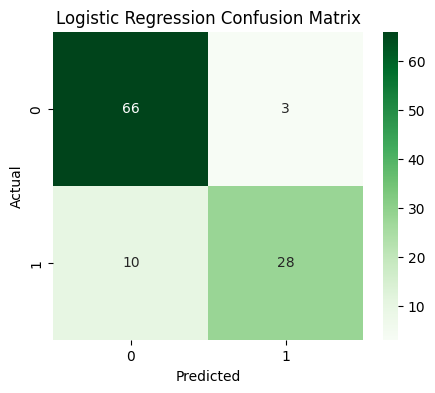

In [38]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance Analysis

### Purpose
Feature importance analysis identifies the most influential clinical and lifestyle-related features contributing to PCOS prediction.

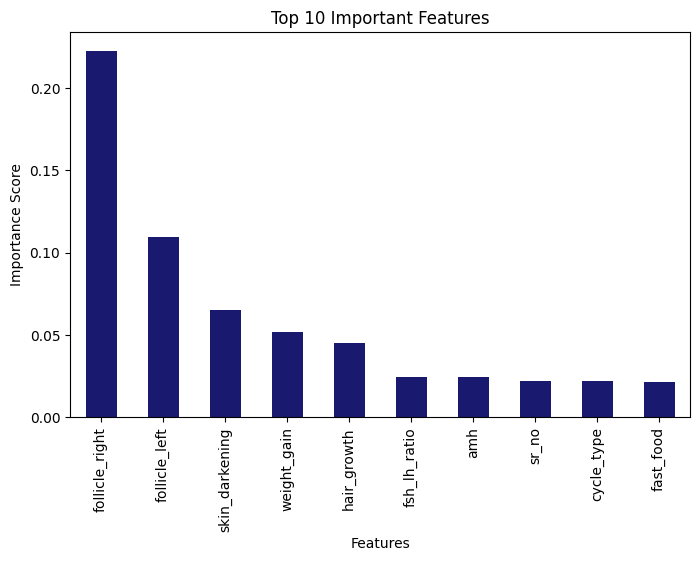

In [39]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=x.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))

importance.head(10).plot(
    kind="bar",
    color="midnightblue"
)

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

### Observation
The feature importance analysis shows that hormonal, metabolic, and reproductive health-related features contribute significantly to PCOS prediction. These features play an important role in machine learning-based disease detection.